# 00 · Data and cleaning

**Question.** What is in the raw data, and what did cleaning keep and why?

The finding, its figure and the numbers come first; how they were produced follows.

Finding: the first cleaning pass kept 1,388,089 of 2,830,743 CIC-IDS2017 rows (49.0%). The fix keeps 1,439,672 flows that report 'no TCP window' instead of deleting them; the evaluation copy keeps 2,827,726 rows (99.9%).


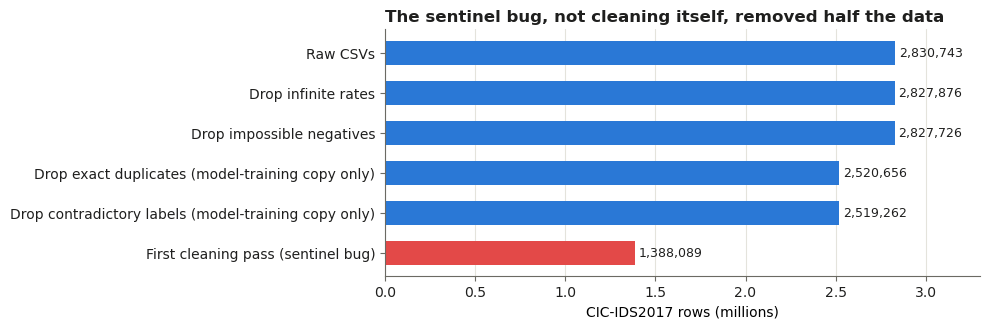

In [1]:
import sys, json, warnings
sys.path.insert(0, "..")  # make src/ importable from notebooks/
warnings.filterwarnings("ignore", message="X does not have valid feature names")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.reporting.plots import load_summary, recall_dots, recall_table, style, COLORS, NAMES, INK, MUTED
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)
REPORTS = "../reports"

m17 = json.load(open(f"{REPORTS}/dataset_v2_manifest.json"))
m17e = json.load(open(f"{REPORTS}/dataset_2017_eval_manifest.json"))
m18 = json.load(open(f"{REPORTS}/dataset_2018_manifest.json"))
m18e = json.load(open(f"{REPORTS}/dataset_2018_eval_manifest.json"))
import pyarrow.parquet as pq
v1_rows = pq.ParquetFile("../data/processed/cicids2017_clean.parquet").metadata.num_rows

print(f"Finding: the first cleaning pass kept {v1_rows:,} of {m17['rows_raw']:,} CIC-IDS2017 rows "
      f"({v1_rows / m17['rows_raw']:.1%}). The fix keeps {m17['sentinel_flows_kept']:,} flows that report "
      f"'no TCP window' instead of deleting them; the evaluation copy keeps {m17e['rows_clean']:,} rows "
      f"({m17e['rows_clean'] / m17e['rows_raw']:.1%}).")

steps = [("Raw CSVs", m17["rows_raw"]),
         ("Drop infinite rates", m17["rows_raw"] - m17["rows_dropped_inf_rates"]),
         ("Drop impossible negatives", m17["rows_raw"] - m17["rows_dropped_inf_rates"] - m17["rows_dropped_negative"]),
         ("Drop exact duplicates (model-training copy only)", m17["rows_clean"] + m17["rows_dropped_contradictory_labels"]),
         ("Drop contradictory labels (model-training copy only)", m17["rows_clean"]),
         ("First cleaning pass (sentinel bug)", v1_rows)]
fig, ax = plt.subplots(figsize=(10, 3.4))
labels, values = zip(*steps)
colors = ["#2a78d6"] * 5 + ["#e34948"]
ax.barh(labels, values, color=colors, height=0.6)
for i, v in enumerate(values):
    ax.text(v + 2e4, i, f"{v:,}", va="center", fontsize=9, color=INK)
ax.invert_yaxis(); ax.set_xlim(0, 3.3e6); ax.set_xlabel("CIC-IDS2017 rows (millions)")
ax.xaxis.set_major_formatter(lambda x, _: f"{x / 1e6:.1f}")
ax.set_title("The sentinel bug, not cleaning itself, removed half the data", loc="left", fontweight="bold", color=INK)
style(ax); fig.tight_layout(); plt.show()

In [2]:
keys = ["rows_raw", "flow_bytes_nan_filled", "rows_dropped_inf_rates", "sentinel_flows_kept",
        "rows_dropped_negative", "rows_dropped_duplicates", "rows_dropped_contradictory_labels", "rows_clean"]
pd.DataFrame({"2017 training copy": [m17[k] for k in keys], "2017 evaluation copy": [m17e[k] for k in keys],
              "2018 training copy": [m18[k] for k in keys], "2018 evaluation copy": [m18e[k] for k in keys]},
             index=keys)

,2017 training copy,2017 evaluation copy,2018 training copy,2018 evaluation copy
rows_raw,2830743,2830743,4096716,4096716
flow_bytes_nan_filled,1358,1358,6684,6684
rows_dropped_inf_rates,2867,2867,10681,10681
sentinel_flows_kept,1439672,1439672,2150019,2150019
rows_dropped_negative,150,150,3,3
rows_dropped_duplicates,307070,0,1557465,0
rows_dropped_contradictory_labels,1394,0,14351,0
rows_clean,2519262,2827726,2514216,4086032


## What the cleaning does

The same code (`src/data/cleaning.py`) cleans both datasets. It strips column names, fixes the
garbled web-attack labels, drops 8 constant columns and one duplicate column, fills genuine
missing rates with 0, and drops rows whose rate columns are infinite or whose counts are negative
where negatives are impossible. Inter-arrival times can be negative in this data and are kept.

**The sentinel bug.** `Init_Win_bytes_forward/backward = -1` means "no TCP window was observed"
(UDP flows, flows without a handshake). The first cleaning pass treated it as corrupt and deleted
those rows: half the dataset, mostly ordinary benign traffic. The fix keeps them, adds
`Has_Init_Win_fwd/bwd` indicator columns, and sets the -1 to 0.

**Two copies of each dataset.**

- *Training copy* (`*_clean*.parquet`): exact duplicates and contradictory labels removed. Used by
  the older reports and the served model.
- *Evaluation copy* (`*_eval.parquet`, `python scripts/build_dataset.py --year YYYY --no-dedup`):
  keeps repeated flows and conflicting labels, because real traffic has both, and because removing
  contradictory labels across the whole dataset uses test labels before any split. All numbered
  notebooks 03-06 use the evaluation copy.

**CSE-CIC-IDS2018.** Its columns are renamed onto the 2017 names (`src/data/cicids2018.py`; all
78 columns map one to one). To fit in memory, 10% of benign flows are kept and every attack flow;
prevalence-dependent metrics weight benign rows by 10.

## Limits

- The first-pass row count comes from the old parquet file, which is kept only for this comparison.
- Cleaning cannot fix label errors in the source data (Engelen, Rimmer & Joosen, 2021).